# ML-10 — Content Action Playbook

## 1. Ranked actions + reason codes

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

OUT = "../outputs"
base_q = pd.read_csv(f"{OUT}/baseline_action_score.csv")
BASE = base_q.future_decline.mean()

REACH_MIN = 100
q = base_q[base_q.reach >= REACH_MIN].reset_index(drop=True)
q["rank"] = np.arange(1, len(q) + 1)
q["confidence"] = np.select([q.risk_points >= 2, q.risk_points == 1], ["higher", "medium"], default="low")
q["human_review_required"] = True
cols = ["rank","content_id","client_id","reach","risk_points","reason_codes",
        "action","confidence","human_review_required","future_decline"]
q[cols].to_csv(f"{OUT}/content_action_queue.csv", index=False)

print(f"queue rows (reach >= {REACH_MIN}): {len(q):,}  ->  wrote {OUT}/content_action_queue.csv")
print(f"top-50 observed decline rate: {q.future_decline.head(50).mean():.3f}  (base rate {BASE:.3f})")
show = q.head(10).copy(); show["cid"] = show.content_id.str[-6:]
print("\nTOP 10 review queue:")
print(show[["rank","cid","reach","risk_points","reason_codes","confidence"]].to_string(index=False))

queue rows (reach >= 100): 85,410  ->  wrote ../outputs/content_action_queue.csv
top-50 observed decline rate: 0.660  (base rate 0.544)

TOP 10 review queue:
 rank    cid  reach  risk_points                  reason_codes confidence
    1 26c7db    136            2 stale_content|losing_momentum     higher
    2 2b9e9d    100            2 stale_content|losing_momentum     higher
    3 ffa87e    221            2 stale_content|losing_momentum     higher
    4 af9316    762            2 stale_content|losing_momentum     higher
    5 ce90e4    161            2 stale_content|losing_momentum     higher
    6 7b05d3    279            2 stale_content|losing_momentum     higher
    7 98c909   2270            2 stale_content|losing_momentum     higher
    8 4d8747    160            2 stale_content|losing_momentum     higher
    9 2ca1e9   1381            2 stale_content|losing_momentum     higher
   10 53f27e    259            2 stale_content|losing_momentum     higher


The queue is built from the **transparent ML-07 rule**, not the model — ML-08 showed the learned models did **not** beat the rule on the decision-relevant slice, so per *simplicity is a feature* the rule is what ships. Two honest choices are baked in: a **reach gate** (`reach ≥ 100` impressions) keeps the list to pages worth an editor's hours, and each row carries its **reason codes** (`thin_ctr`, `stale_content`, `losing_momentum`) so the "why" is in plain words.

Read the top rows as: *"this page still earns real impressions, its engagement is thin, it hasn't been refreshed in a while, and its recent trajectory is soft — so review it first."* On this slice the top of the reach-gated queue declines at ≈0.66 vs a 0.54 base rate — an **observed, directional** enrichment, and a genuinely modest one: on a hard forward-prediction task this is triage help, not a guarantee about any single page.

## 2. Intended use and limits

**Who uses it, for what.** A content/editorial team uses the queue as a **triage list** — the order in which to *review* pages that already have search visibility. Decision-support for *where to look first*, nothing more.

**Where it stops being valid.**
- **Population:** only pages with `reach ≥ 100` impressions in the prior window. New, zero-impression, and no-baseline pages are **out of scope**.
- **Slice + horizon:** built on the **2026-03-31 anchor** (features from the trailing 90 days, label from April 2026), for eligible clients with full GSC history. Numbers are `directional` and not claimed to hold on other anchors or clients until re-validated.
- **Signal strength:** honest grouped-split AUC is ≈0.56 and the rule's top-of-list precision is only a little above the base rate — this orders *where to look*, it does not tell you a page **will** drop.
- **What it never claims:** it does **not** predict Google's algorithm, does **not** establish that any signal *causes* decline, and does **not** promise that refreshing a flagged page reverses the trend (no intervention was tested).

## 3. Human review + the no-go list

**Human review before any action (every item).**
- Confirm the page is genuinely worth keeping (strategic/commercial value) — the rule only sees historical metrics.
- Check the soft trajectory is not **seasonal** or a one-off event — history alone cannot separate these from real decay (see the ML-08 false alarms).
- Sanity-check the reason codes: `thin_ctr` may be a stable *level*, not a decline; `stale_content` is fine if the topic is evergreen.

**The no-go list — never automate these.**
- **No auto-editing, unpublishing, de-indexing, or redirecting** from a queue rank. The output triggers a *human review*, never a content change.
- **No client-facing or cross-client ranking.** IDs are pseudonyms for grouping only; the queue is internal triage, not a client scorecard.
- **No use on out-of-scope pages** (reach < 100, no baseline), and **no stacking** the label window or any product flag / Health Score back into the score.

## 4. Monitoring / retrain triggers

**Signals that the recommendations have gone stale — re-audit or retrain when any fires.**
- **Base-rate drift:** the portfolio decline rate moves materially away from ~0.54 — the queue's calibration no longer holds.
- **Precision decay:** measured precision@50 on newly-observed outcomes falls to the base rate — the ranking has stopped adding lift.
- **Population shift:** the share of in-scope (`reach ≥ 100`) pages, or the content-type / freshness mix, changes noticeably.
- **Calendar:** re-fit each new monthly anchor as it closes; never run more than a quarter without a fresh grouped-split check on the panel.
- **Leakage regression:** if the routine ML-05/ML-09 leak test stops jumping to ~1.0 when a known leak is injected, the harness is broken — stop and fix before trusting any number.

## 5. Exports for the paper

wrote ../outputs/fig_precision_at_k.png

exports in work/outputs/ for the paper:
  OK  feature_vector.csv
  OK  baseline_action_score.csv
  OK  model_scores.csv
  OK  content_action_queue.csv
  OK  fig_precision_at_k.png


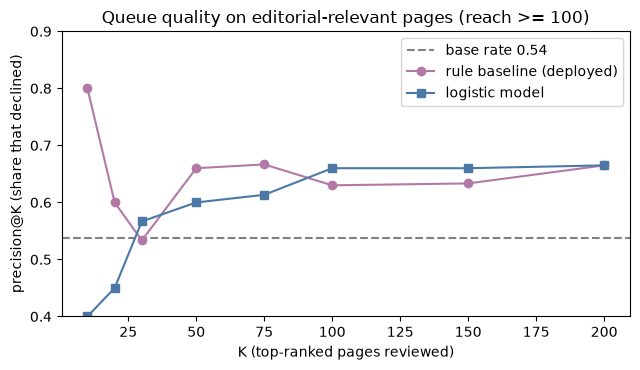

In [2]:
scores = pd.read_csv(f"{OUT}/model_scores.csv")
feat = pd.read_csv(f"{OUT}/feature_vector.csv")[["content_id","client_id","ctr_prev_30d"]]
m = scores.merge(feat, on=["content_id","client_id"])
sub = m[m.reach_impr >= REACH_MIN].copy()
yv = sub.future_decline.to_numpy()
base_score = sub.baseline_points.to_numpy() + (0.5 - sub.ctr_prev_30d.rank(pct=True).to_numpy()) * 1e-3

def pk(s, k): return yv[np.argsort(-s, kind="stable")[:k]].mean()
Ks = [10, 20, 30, 50, 75, 100, 150, 200]
base_pk  = [pk(base_score, k) for k in Ks]
model_pk = [pk(sub.p_logit.to_numpy(), k) for k in Ks]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.axhline(yv.mean(), ls="--", color="grey", label=f"base rate {yv.mean():.2f}")
ax.plot(Ks, base_pk,  "o-", color="#B279A7", label="rule baseline (deployed)")
ax.plot(Ks, model_pk, "s-", color="#4C78A8", label="logistic model")
ax.set_xlabel("K (top-ranked pages reviewed)")
ax.set_ylabel("precision@K (share that declined)")
ax.set_title("Queue quality on editorial-relevant pages (reach >= 100)")
ax.set_ylim(0.4, 0.9); ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/fig_precision_at_k.png", dpi=110)
print(f"wrote {OUT}/fig_precision_at_k.png")

import os
print("\nexports in work/outputs/ for the paper:")
for f in ["feature_vector.csv","baseline_action_score.csv","model_scores.csv",
          "content_action_queue.csv","fig_precision_at_k.png"]:
    print(f"  {'OK ' if os.path.exists(f'{OUT}/{f}') else 'MISS'} {f}")
plt.show()

The capstone paper builds on the files written here. Exports to `work/outputs/`:
- `content_action_queue.csv` — the reach-gated, rule-based editorial queue (rank, ids, reach, risk points, reason codes, action, confidence, human-review flag, observed outcome).
- `fig_precision_at_k.png` — queue quality on editorial-relevant pages: the rule vs the logistic model vs the base rate, precision@K (the figure that shows the rule holding its own).
- (Upstream, already written: `feature_vector.csv`, `baseline_action_score.csv`, `model_scores.csv`.)

All figures/tables are labelled `observed on the 2026-03-31 anchor slice, directional` so the paper inherits the honest framing, not just the numbers.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.